# Visualise a serialized image dataset in 2D

Load a prepared dataset artifact, optionally load a MIMIC embedding artifact, first plot a PCA view of the full dataset, then build a separate reference-axis projection from three selected images.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

import numpy as np
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "vision" / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

VISION_SRC = PROJECT_ROOT / "vision" / "src"
if str(VISION_SRC) not in sys.path:
    sys.path.insert(0, str(VISION_SRC))

from mimic_vision.datasets import load_serialized_vision_dataset, load_serialized_vision_embedding
from mimic_vision.visualization import (
    compute_2d_embedding,
    plot_image_embedding,
    plot_reference_axis_embedding,
    plot_reference_images,
)

In [3]:
DATASET_FILE = "mnist_train_n400_classes-3-8_28x28.pkl"
EMBEDDING_FILE = None  # Example: "mnist_train_n400_classes-3-8_28x28_mimic-direct_cap0p0_emb784.pkl"
INPUT_DIR = PROJECT_ROOT / "vision" / "data" / "serialized"
EMBEDDING_DIR = PROJECT_ROOT / "vision" / "data" / "embeddings"
FULL_LAYOUT_METHOD = "pca"
RANDOM_STATE = 0
PROJECTION_SPACE = "raw"  # "raw" or "embedding"

In [4]:
dataset = load_serialized_vision_dataset(DATASET_FILE, input_dir=INPUT_DIR)
dataset.X.shape, dataset.images.shape, dataset.y.value_counts().sort_index()

((400, 784),
 (400, 28, 28),
 target
 3    200
 8    200
 Name: count, dtype: int64)

## PCA view

Plot the full loaded dataset with PCA coordinates and non-overlapping image thumbnails.

In [5]:
pca_coordinates = compute_2d_embedding(dataset.X, method=FULL_LAYOUT_METHOD, random_state=RANDOM_STATE)
pca_coordinates.shape

(400, 2)

103

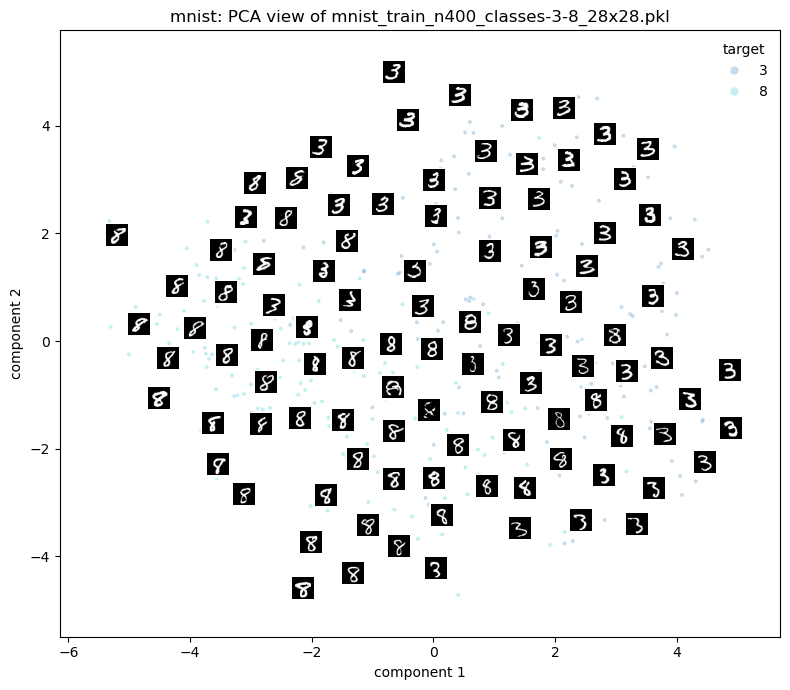

In [6]:
fig_pca, ax_pca, shown_pca = plot_image_embedding(
    pca_coordinates,
    dataset.images,
    labels=dataset.y,
    target_names=dataset.target_names,
    title=f"{dataset.name}: PCA view of {DATASET_FILE}",
    max_images=180,
    min_distance_px=32,
    zoom=0.55,
)
len(shown_pca)

## Reference-axis view

Select three reference images `O`, `X`, and `Y`, display them, then project the dataset onto orthogonal axes derived from those references.

In [7]:
embedding_artifact = None
embedding_vectors = None
if EMBEDDING_FILE is not None:
    embedding_artifact = load_serialized_vision_embedding(EMBEDDING_FILE, input_dir=EMBEDDING_DIR)
    if embedding_artifact.dataset_file != DATASET_FILE:
        raise ValueError(f"Embedding artifact was created for {embedding_artifact.dataset_file}, not {DATASET_FILE}.")
    embedding_vectors = embedding_artifact.embeddings

None if embedding_vectors is None else embedding_vectors.shape

{'O': 269, 'X': 90, 'Y': 323}

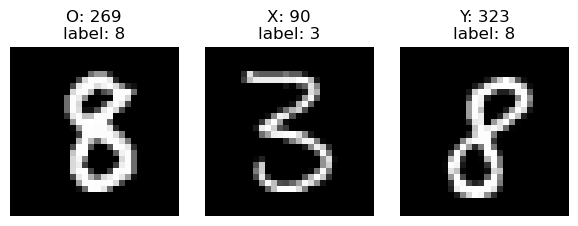

In [11]:
rng = np.random.default_rng()
reference_indices = rng.choice(len(dataset.images), size=3, replace=False)
references = dict(zip(["O", "X", "Y"], reference_indices.tolist()))

fig_refs, axes_refs = plot_reference_images(
    dataset.images,
    references,
    labels=dataset.y,
    target_names=dataset.target_names,
)
references

62

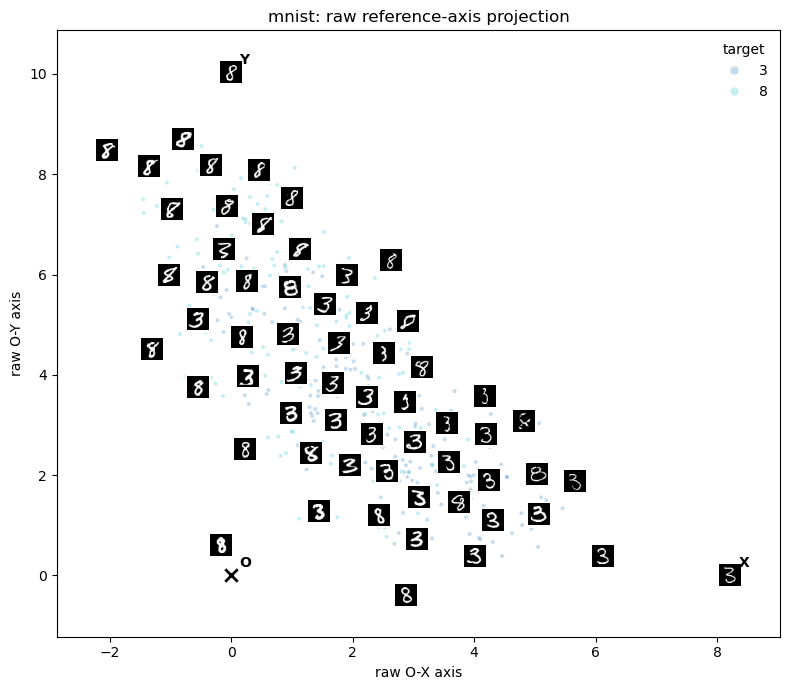

In [12]:
fig_ref, ax_ref, shown_ref, reference_coordinates = plot_reference_axis_embedding(
    dataset.X,
    dataset.images,
    references=references,
    vector_space=PROJECTION_SPACE,
    embedding_vectors=embedding_vectors,
    labels=dataset.y,
    target_names=dataset.target_names,
    title=f"{dataset.name}: {PROJECTION_SPACE} reference-axis projection",
    max_images=180,
    min_distance_px=32,
    zoom=0.55,
)
len(shown_ref)